# DNA Translation and Pairwise Identity Workflow

This notebook:
- loads DNA FASTA sequences from `data/raw/`
- translates them into proteins
- saves translated proteins to `data/processed/translated_proteins.fasta`
- computes pairwise identity scores
- saves the score table to `outputs/tables/identity_scores.csv`
- plots a scatter plot and saves it to `outputs/figures/identity_scores_scatter.png`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.bioseq import all_pairwise_identity_scores, translate_dna_sequence

raw_dir = Path('../data/raw')
processed_dir = Path('../data/processed')
figures_dir = Path('../outputs/figures')
tables_dir = Path('../outputs/tables')

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)


C:\Users\vvsha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
fasta_files = list(raw_dir.glob('*.fasta'))
if not fasta_files:
    raise FileNotFoundError('No FASTA files found in data/raw/')

dna_records = []
for fasta_file in fasta_files:
    dna_records.extend(list(SeqIO.parse(fasta_file, 'fasta')))

print(f'Loaded {len(dna_records)} DNA sequences')


Loaded 3 DNA sequences


In [3]:
protein_records = []
for record in dna_records:
    protein_seq = translate_dna_sequence(str(record.seq))
    protein_records.append((record.id, protein_seq))

protein_output = processed_dir / 'translated_proteins.fasta'
with open(protein_output, 'w') as handle:
    for record_id, protein_seq in protein_records:
        handle.write(f'>{record_id}\n{protein_seq}\n')

print(f'Saved translated proteins to {protein_output}')


Saved translated proteins to ..\data\processed\translated_proteins.fasta


In [4]:
scores = all_pairwise_identity_scores(protein_records)
scores_df = pd.DataFrame(scores)
scores_df


,seq_a,seq_b,identity_score
0,seq1,seq2,100.0
1,seq1,seq3,75.0
2,seq2,seq3,75.0


In [5]:
table_output = tables_dir / 'identity_scores.csv'
scores_df.to_csv(table_output, index=False)
print(f'Saved identity score table to {table_output}')


Saved identity score table to ..\outputs\tables\identity_scores.csv


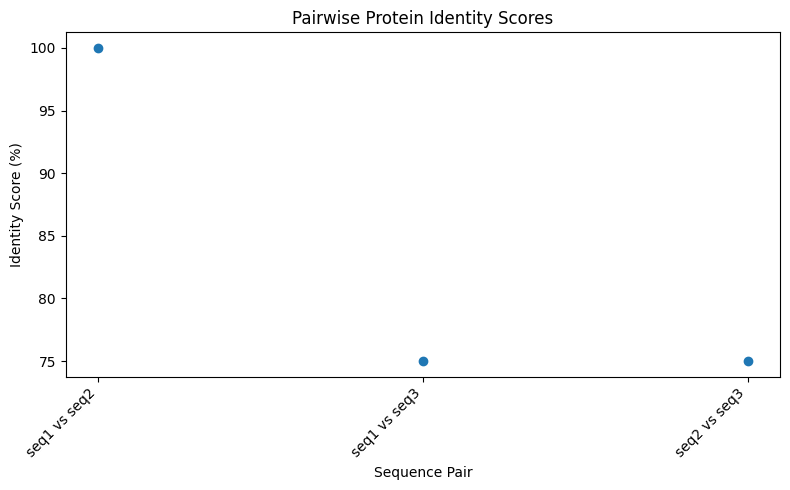

Saved figure to ..\outputs\figures\identity_scores_scatter.png


In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(scores_df)), scores_df['identity_score'])
plt.xticks(range(len(scores_df)), [f"{a} vs {b}" for a, b in zip(scores_df['seq_a'], scores_df['seq_b'])], rotation=45, ha='right')
plt.ylabel('Identity Score (%)')
plt.xlabel('Sequence Pair')
plt.title('Pairwise Protein Identity Scores')
plt.tight_layout()

figure_output = figures_dir / 'identity_scores_scatter.png'
plt.savefig(figure_output, dpi=300)
plt.show()

print(f'Saved figure to {figure_output}')
